# script to calculate the absolute coordinates of head position measured with DLC from center coordinates
(excluded worms from june head position has more oordinates then center stage)

In [1]:
#Importing the toolbox (takes several seconds)
import pandas as pd
from pathlib import Path
import numpy as np
import os
import matplotlib.pyplot as plt
import tifffile as tiff
from natsort import natsorted
import glob

In [2]:
from coordinate_conversion_functions import *
from track_plotting_functions import *

## read in data

In [3]:
#this are the center coordinates
path_center_coords='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_tracks/2020-07-01_17-01-27_chemotaxis_worm6-TablePosRecord.txt'
df_center_coords=pd.read_csv(path_center_coords)

In [4]:
#this are the head and tail positions measured via dlc
path_head_tail='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_17-01-27_chemotaxis_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5'
df_head_tail_coords=pd.read_hdf(path_head_tail, low_memory=False)

In [5]:
df_center_coords

,time,xc,x,yc,y
0,17:01:30.648,x,33.4918,y,9.3320
1,17:01:30.665,x,33.4918,y,9.3320
2,17:01:30.665,x,33.4918,y,9.3320
3,17:01:30.665,x,33.4918,y,9.3320
4,17:01:30.680,x,33.4911,y,9.3314
...,...,...,...,...,...
199996,17:21:30.657,x,9.0679,y,16.2026
199997,17:21:30.673,x,9.0679,y,16.2025
199998,17:21:30.673,x,9.0679,y,16.2024
199999,17:21:30.689,x,9.0679,y,16.2021


# get absolute head and tail coordinates

In [6]:
df_head_tail_center_coords=df_center_coords #create new df in which corrected x and y position will be in
scorer=df_head_tail_coords.columns.get_level_values(0)[0] # defines scorer as the first column of the dataframe
df_head_tail_center_coords

,time,xc,x,yc,y
0,17:01:30.648,x,33.4918,y,9.3320
1,17:01:30.665,x,33.4918,y,9.3320
2,17:01:30.665,x,33.4918,y,9.3320
3,17:01:30.665,x,33.4918,y,9.3320
4,17:01:30.680,x,33.4911,y,9.3314
...,...,...,...,...,...
199996,17:21:30.657,x,9.0679,y,16.2026
199997,17:21:30.673,x,9.0679,y,16.2025
199998,17:21:30.673,x,9.0679,y,16.2024
199999,17:21:30.689,x,9.0679,y,16.2021


In [7]:
#defining the parameters for the function to calulate the corrected head and tail positions
px_mm=0.00325 # this value represents how much mm is one pixel
x_lenght_frame=608 #lenght of x axis in frame (measured with fiji)
y_width_frame=610 #width of the y axis in frame
center_x=df_head_tail_center_coords['x'] #absolute coordinates of center position x
center_y=df_head_tail_center_coords['y'] #absolute coordinates of center position y
data_head_x=df_head_tail_coords[scorer]['Head']['x'].values #getting the x position of head
data_head_y=df_head_tail_coords[scorer]['Head']['y'].values #getting the y position of head
data_tail_x=df_head_tail_coords[scorer]['Tail']['x'].values #getting the x position of tail
data_tail_y=df_head_tail_coords[scorer]['Tail']['y'].values #getting the y position of tail

In [8]:
#caclulates corrected head and tail position adjusts to xref and puts them as columns
xref=9.1
df_head_tail_center_coords['x_head_corrected']= corrected_absolute_coordinates(center_x,data_head_x,px_mm,x_lenght_frame)-xref
df_head_tail_center_coords['y_head_corrected']= corrected_absolute_coordinates(center_y,data_head_y,px_mm,y_width_frame)
df_head_tail_center_coords['x_tail_corrected']= corrected_absolute_coordinates(center_x,data_tail_x,px_mm,x_lenght_frame)-xref
df_head_tail_center_coords['y_tail_corrected']= corrected_absolute_coordinates(center_y,data_tail_y,px_mm,y_width_frame)
df_head_tail_center_coords

,time,xc,x,yc,y,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected
0,17:01:30.648,x,33.4918,y,9.3320,24.113237,9.637782,24.772702,8.856654
1,17:01:30.665,x,33.4918,y,9.3320,24.111831,9.637576,24.770871,8.855784
2,17:01:30.665,x,33.4918,y,9.3320,24.110368,9.637576,24.770833,8.855473
3,17:01:30.665,x,33.4918,y,9.3320,24.109364,9.637044,24.770249,8.854743
4,17:01:30.680,x,33.4911,y,9.3314,24.107782,9.636437,24.767937,8.853914
...,...,...,...,...,...,...,...,...,...
199996,17:21:30.657,x,9.0679,y,16.2026,-0.215990,16.609582,-0.100571,15.680879
199997,17:21:30.673,x,9.0679,y,16.2025,-0.215930,16.609482,-0.100528,15.680779
199998,17:21:30.673,x,9.0679,y,16.2024,-0.215930,16.609382,-0.100528,15.680782
199999,17:21:30.689,x,9.0679,y,16.2021,-0.215362,16.609082,-0.100230,15.680482


In [23]:
a=[1,2,10,1]

In [24]:
len(a)

4

In [ ]:
a.

In [29]:
a.shape

AttributeError: 'list' object has no attribute 'shape'

In [25]:
a_a=np.array(a)

In [28]:
a_a.shape

(4,)

In [ ]:
center_x.

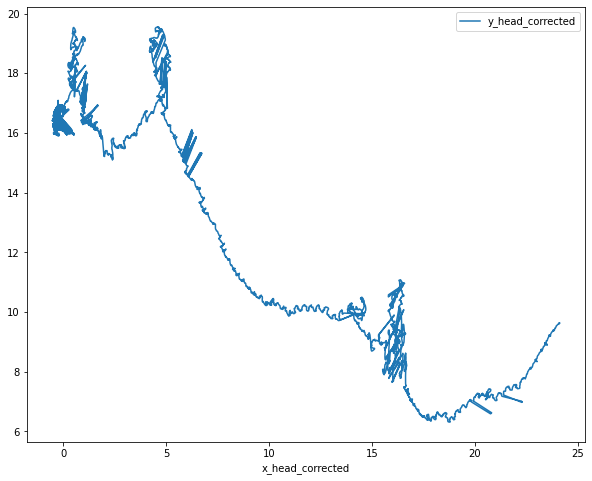

In [9]:
df_head_tail_center_coords.plot(x='x_head_corrected', y='y_head_corrected', figsize=(10,8))

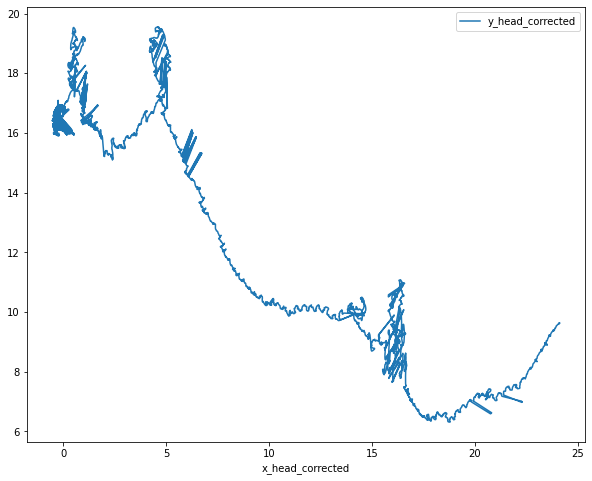

In [10]:
df_head_tail_center_coords.plot(x='x_head_corrected', y='y_head_corrected', figsize=(10,8))

In [31]:
df_head_tail_center_coords.plt.scatter(x='x_head_corrected', y='y_head_corrected', cmap='concentration_head', figsize=(10,8))

AttributeError: 'DataFrame' object has no attribute 'plt'

# calculate and plot concentration change

In [11]:
#this is telling you the concentration of every x position occuring in the data
#since it is a stripe assay only the x coordinates matter for concentration change
#parameters determined via the curve fit script
L=1
x0=3.81953189
k=-0.69421567
b=0
x_head_corrected=df_head_tail_center_coords['x_head_corrected'].values #xref adust gradient for food position
x_tail_corrected=df_head_tail_center_coords['x_tail_corrected'].values
y_fit_head=sigmoid(x_head_corrected, L, x0, k, b)
y_fit_tail=sigmoid(x_tail_corrected, L, x0, k, b)

In [12]:
#creating df with x head/tail position and the corresponding concentration
position_concentration = pd.DataFrame(data=x_head_corrected,columns=["x_head_corrected"])
position_concentration['x_tail_corrected']=pd.DataFrame(data=x_tail_corrected,columns=["x_tail_corrected"])
position_concentration['Concentration_head']=y_fit_head
position_concentration['Concentration_tail']=y_fit_tail
position_concentration

,x_head_corrected,x_tail_corrected,Concentration_head,Concentration_tail
0,24.113237,24.772702,7.613223e-07,4.816638e-07
1,24.111831,24.770871,7.620660e-07,4.822763e-07
2,24.110368,24.770833,7.628402e-07,4.822890e-07
3,24.109364,24.770249,7.633720e-07,4.824849e-07
4,24.107782,24.767937,7.642109e-07,4.832596e-07
...,...,...,...,...
199996,-0.215990,-0.100571,9.427580e-01,9.382775e-01
199997,-0.215930,-0.100528,9.427558e-01,9.382757e-01
199998,-0.215930,-0.100528,9.427558e-01,9.382757e-01
199999,-0.215362,-0.100230,9.427345e-01,9.382638e-01


In [13]:
#calculating concentration change
concentration_change=position_concentration
concentration_change["Concentration_change_head"] = position_concentration["Concentration_head"].diff()
concentration_change["Concentration_change_tail"] = position_concentration["Concentration_tail"].diff()
concentration_change

,x_head_corrected,x_tail_corrected,Concentration_head,Concentration_tail,Concentration_change_head,Concentration_change_tail
0,24.113237,24.772702,7.613223e-07,4.816638e-07,NaN,NaN
1,24.111831,24.770871,7.620660e-07,4.822763e-07,7.437294e-10,6.124539e-10
2,24.110368,24.770833,7.628402e-07,4.822890e-07,7.741842e-10,1.278468e-11
3,24.109364,24.770249,7.633720e-07,4.824849e-07,5.317321e-10,1.958306e-10
4,24.107782,24.767937,7.642109e-07,4.832596e-07,8.389519e-10,7.747254e-10
...,...,...,...,...,...,...
199996,-0.215990,-0.100571,9.427580e-01,9.382775e-01,0.000000e+00,0.000000e+00
199997,-0.215930,-0.100528,9.427558e-01,9.382757e-01,-2.251766e-06,-1.750544e-06
199998,-0.215930,-0.100528,9.427558e-01,9.382757e-01,0.000000e+00,0.000000e+00
199999,-0.215362,-0.100230,9.427345e-01,9.382638e-01,-2.126582e-05,-1.199187e-05


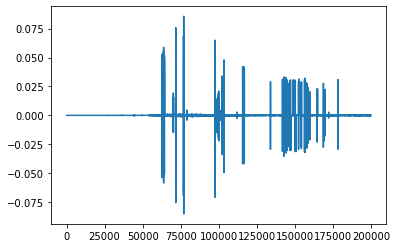

In [14]:
#plot concentration change over time
y_head=concentration_change['Concentration_change_head']
y_tail=concentration_change['Concentration_change_tail']
x = np.arange(200001)
plt.plot(x,y_head)
plt.show()

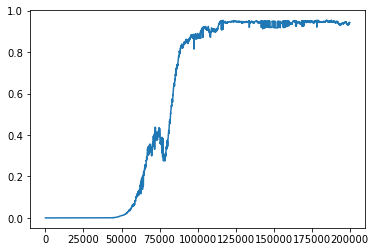

In [16]:
concentration_change['Concentration_head'].plot()

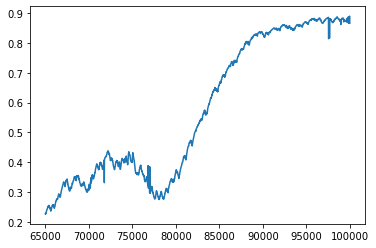

In [18]:
concentration_change[65000:100000]['Concentration_head'].plot()

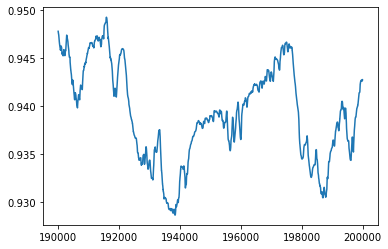

In [15]:
concentration_change[190000:200000]['Concentration_head'].plot()

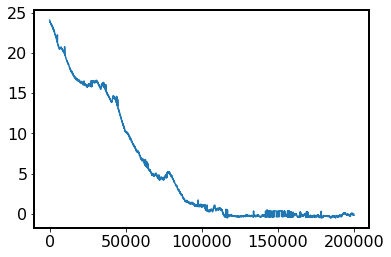

In [147]:
#x positition of head vs time
concentration_change['x_head_corrected'].plot()

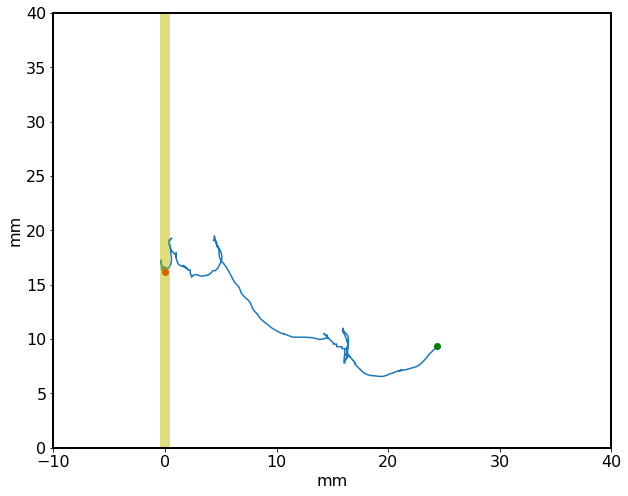

In [58]:
plot_tracks_with_ref(path_center_coords,9.1)

Text(0, 0.5, '∆C')

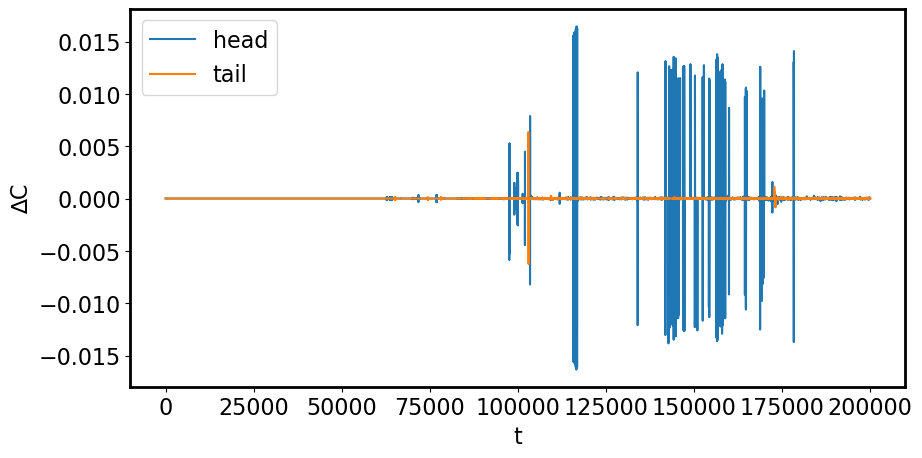

In [59]:
fig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=100)
ax3.plot(x,y_head,label="head")
ax3.plot(x,y_tail,label="tail")
ax3.legend()
plt.xlabel("t")
plt.ylabel("∆C")

Annotations